In [ ]:
from google.colab import files
uploaded = files.upload()


Saving sample_mental_health_chatbot_2480_data (4).xlsx to sample_mental_health_chatbot_2480_data (4).xlsx


In [ ]:
import pandas as pd

# Replace this with the uploaded filename
# file_name = 'cb81a41e-5d57-4e35-b1f5-c69e38cd9f64.xlsx' # Original incorrect line
file_name = list(uploaded.keys())[0] # Get the actual filename from the uploaded dictionary

# Load the Excel file
df = pd.read_excel(file_name, sheet_name='sample_mental_health_chatbot_20')

# Preview the first few rows
df.head()

,text,emotion,sentiment,intent,bot_response,is_suicidal,source,timestamp,annotator_notes
0,নিজেকে শেষ করে ফেলতে ইচ্ছা করছে।,suicidal,hopeless,cry_for_help,আপনি একা নন। সাহায্যের জন্য হেল্পলাইন নম্বরে য...,True,form_response,2025-12-03 02:42:18,High-risk phrase
1,আমি খুব একা অনুভব করছি।,sad,negative,need_help,আমি বুঝতে পারছি আপনি কষ্টে আছেন।,False,synthetic,2025-08-16 06:01:21,NaN
2,আজকে আবহাওয়া খুব ভালো।,happy,positive,greet,দারুন শুনে ভালো লাগলো!,False,synthetic,2024-07-17 14:54:26,NaN
3,চিন্তা বন্ধ হচ্ছে না।,anxious,stressed,academic_stress,চাপ অনুভব করা স্বাভাবিক। আপনি এক ধাপে একধাপ এগ...,False,form_response,2025-04-20 12:30:59,NaN
4,বন্ধুদের সাথে সময়টা দারুণ কাটলো!,happy,positive,greet,দারুন শুনে ভালো লাগলো!,False,form_response,2024-04-07 23:50:08,NaN


In [ ]:
import re

def clean_bangla(text):
    text = text.lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)  # Keep only Bangla characters
    return text

df['clean_text'] = df['text'].astype(str).apply(clean_bangla)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])

# Labels
y = df['emotion']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train classifier
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     anxious       1.00      0.99      0.99        92
    confused       1.00      1.00      1.00       111
       happy       0.98      0.91      0.94       102
         sad       0.85      1.00      0.92        93
    suicidal       0.99      0.91      0.95        98

    accuracy                           0.96       496
   macro avg       0.96      0.96      0.96       496
weighted avg       0.97      0.96      0.96       496



In [ ]:
def generate_response(user_input):
    cleaned = clean_bangla(user_input)
    vect_input = vectorizer.transform([cleaned])
    predicted_emotion = model.predict(vect_input)[0]

    # Get matching bot response from training data
    match = df[df['emotion'] == predicted_emotion].iloc[0]['bot_response']
    return predicted_emotion, match

# Example
user_input = "আমি খুব কষ্টে আছি।"
emotion, response = generate_response(user_input)
print("Predicted Emotion:", emotion)
print("Bot Response:", response)


Predicted Emotion: sad
Bot Response: আমি বুঝতে পারছি আপনি কষ্টে আছেন।


In [ ]:
!pip install transformers datasets sentencepiece --quiet
!pip install openpyxl pandas scikit-learn --quiet


In [ ]:
import pandas as pd

# Load Excel file
# Replace this with the uploaded filename
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name="sample_mental_health_chatbot_20")

# Keep only needed columns
df = df[['text', 'emotion', 'bot_response']].dropna()

# Reset index and rename for clarity
df = df.rename(columns={'text': 'input_text', 'emotion': 'label'})
df = df.reset_index(drop=True)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Show classes
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label map:", label_map)

Label map: {'anxious': np.int64(0), 'confused': np.int64(1), 'happy': np.int64(2), 'sad': np.int64(3), 'suicidal': np.int64(4)}


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['input_text'].tolist(),
    df['label_encoded'].tolist(),
    test_size=0.2,
    random_state=42
)


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch

# Load tokenizer and model (Multilingual BERT or Bangla BERT)
model_name = "sagorsarker/bangla-bert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_map))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize_function(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

train_dataset = Dataset.from_dict({"text": train_texts, "label": train_labels}).map(tokenize_function, batched=True)
val_dataset = Dataset.from_dict({"text": val_texts, "label": val_labels}).map(tokenize_function, batched=True)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])


Map:   0%|          | 0/1984 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/496 [00:00<?, ? examples/s]

In [ ]:
training_args = TrainingArguments(
    output_dir="./bangla-bert-emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    report_to="none" # Explicitly disable reporting to any service
)

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

# No need to install wandb if it's disabled
# !pip install wandb --quiet

In [ ]:
import pandas as pd
from datasets import Dataset

# Convert to pandas DataFrames
train_df = train_dataset.to_pandas()
val_df = val_dataset.to_pandas()

# Convert back to Datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# Set format again
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
def predict_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs).item()
    label = le.inverse_transform([pred])[0]

    # Find matching response
    match = df[df['label'] == label].iloc[0]['bot_response']
    return label, match

# Example
user_input = "আমি খুব কষ্টে আছি"
predicted_emotion, response = predict_emotion(user_input)
print("Emotion:", predicted_emotion)
print("Bot Response:", response)


Emotion: happy
Bot Response: দারুন শুনে ভালো লাগলো!


In [ ]:
import pandas as pd

# Load your uploaded Excel file
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name="sample_mental_health_chatbot_20")

# Keep only needed columns
df = df[['text', 'emotion', 'bot_response']].dropna()
df = df.rename(columns={'text': 'input_text', 'emotion': 'label'})
df.head()

,input_text,label,bot_response
0,নিজেকে শেষ করে ফেলতে ইচ্ছা করছে।,suicidal,আপনি একা নন। সাহায্যের জন্য হেল্পলাইন নম্বরে য...
1,আমি খুব একা অনুভব করছি।,sad,আমি বুঝতে পারছি আপনি কষ্টে আছেন।
2,আজকে আবহাওয়া খুব ভালো।,happy,দারুন শুনে ভালো লাগলো!
3,চিন্তা বন্ধ হচ্ছে না।,anxious,চাপ অনুভব করা স্বাভাবিক। আপনি এক ধাপে একধাপ এগ...
4,বন্ধুদের সাথে সময়টা দারুণ কাটলো!,happy,দারুন শুনে ভালো লাগলো!


In [ ]:
import re

def clean_bangla(text):
    text = str(text).lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)  # Keep Bangla characters
    return text

df['clean_text'] = df['input_text'].apply(clean_bangla)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

# TF-IDF vectorizer
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Logistic Regression
model = LogisticRegression()
model.fit(X_train_vec, y_train)


LogisticRegression()

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     anxious       1.00      0.99      0.99        92
    confused       1.00      1.00      1.00       111
       happy       0.98      0.91      0.94       102
         sad       0.85      1.00      0.92        93
    suicidal       0.99      0.91      0.95        98

    accuracy                           0.96       496
   macro avg       0.96      0.96      0.96       496
weighted avg       0.97      0.96      0.96       496



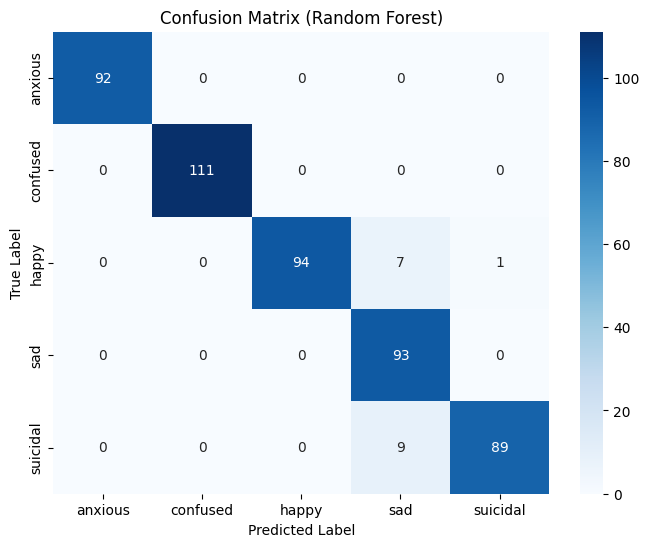

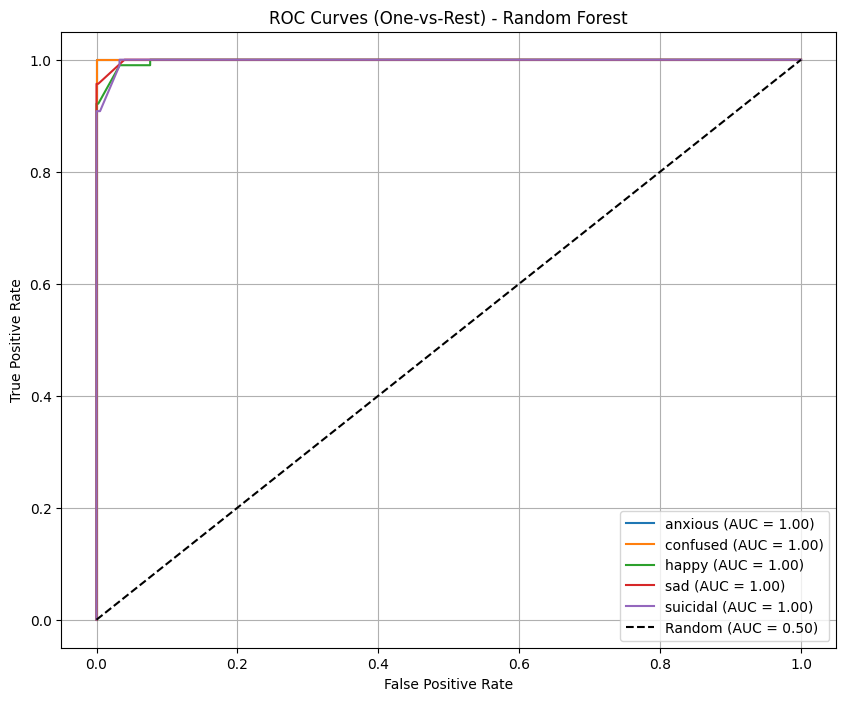

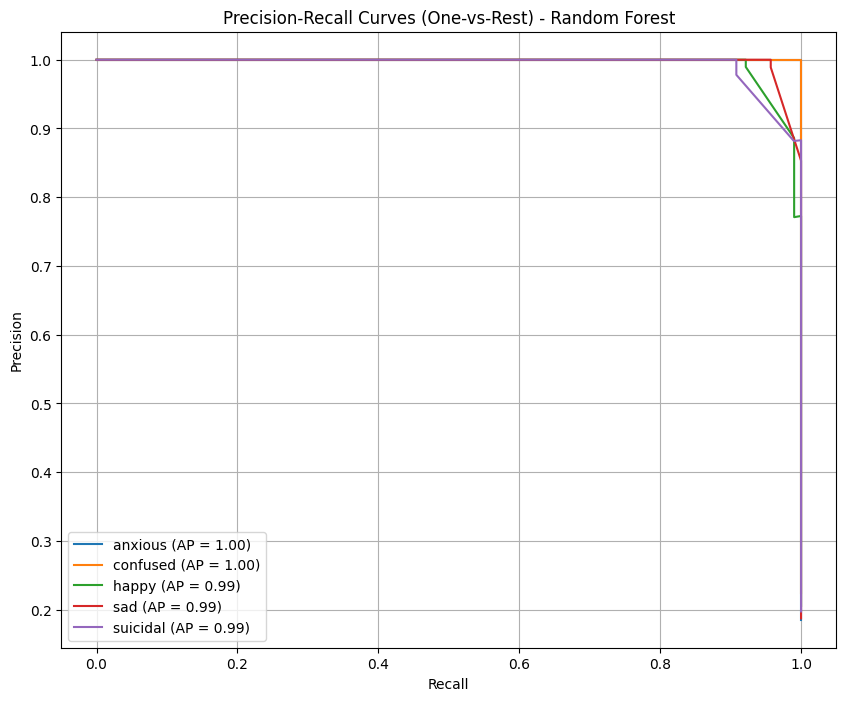

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from sklearn.ensemble import RandomForestClassifier # Import RandomForestClassifier
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Assuming X_train_vec, X_test_vec, y_train, and y_test are available from previous cells

# Train Random Forest Classifier (Add this back in)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)

# Predict on the test set (Add this back in)
y_pred_rf = rf_model.predict(X_test_vec)
y_pred_proba_rf = rf_model.predict_proba(X_test_vec) # Probabilities needed for some metrics

# Class-wise Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

# ROC Curves (One-vs-Rest) - Represents a form of "Accuracy Curve"
try:
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    class_labels = rf_model.classes_

    plt.figure(figsize=(10, 8))
    for i in range(len(class_labels)):
        class_name = class_labels[i]
        if y_test_bin[:, i].sum() > 0:
            fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
            roc_auc_rf = auc(fpr_rf, tpr_rf)
            plt.plot(fpr_rf, tpr_rf, label=f'{class_name} (AUC = {roc_auc_rf:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest) - Random Forest')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

except AttributeError:
    print("\nROC Curves not available. Random Forest model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not plot ROC curves for Random Forest. Error: {e}")


# Precision-Recall Curves (One-vs-Rest) - Can be related to "Loss Curve" in some interpretations
try:
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)
    class_labels = rf_model.classes_

    plt.figure(figsize=(10, 8))
    for i in range(len(class_labels)):
        class_name = class_labels[i]
        if y_test_bin[:, i].sum() > 0:
            precision_rf, recall_rf, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
            ap_rf = average_precision_score(y_test_bin[:, i], y_pred_proba_rf[:, i])
            plt.plot(recall_rf, precision_rf, label=f'{class_name} (AP = {ap_rf:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves (One-vs-Rest) - Random Forest')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

except AttributeError:
    print("\nPrecision-Recall Curves not available. Random Forest model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not plot Precision-Recall curves for Random Forest. Error: {e}")

In [ ]:
def generate_bot_response(user_input):
    cleaned = clean_bangla(user_input)
    vect_input = vectorizer.transform([cleaned])
    predicted_emotion = model.predict(vect_input)[0]

    # Pick any matching response from training data
    match = df[df['label'] == predicted_emotion].iloc[0]['bot_response']
    return predicted_emotion, match

# Try it
text = "আমি খুব একা অনুভব করছি"
emotion, response = generate_bot_response(text)
print("Predicted Emotion:", emotion)
print("Bot Response:", response)


Predicted Emotion: sad
Bot Response: আমি বুঝতে পারছি আপনি কষ্টে আছেন।


In [ ]:
import re

def clean_bangla(text):
    text = str(text).lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    return text

df['clean_text'] = df['input_text'].apply(clean_bangla)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_vec, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     anxious       1.00      1.00      1.00        92
    confused       1.00      1.00      1.00       111
       happy       1.00      0.92      0.96       102
         sad       0.85      1.00      0.92        93
    suicidal       0.99      0.91      0.95        98

    accuracy                           0.97       496
   macro avg       0.97      0.97      0.97       496
weighted avg       0.97      0.97      0.97       496



In [ ]:
def generate_bot_response(user_input):
    cleaned = clean_bangla(user_input)
    vect_input = vectorizer.transform([cleaned])
    predicted_emotion = model.predict(vect_input)[0]

    # Sample response from dataset
    response = df[df['label'] == predicted_emotion].iloc[0]['bot_response']
    return predicted_emotion, response

# Example
emotion, response = generate_bot_response("আমি খুব হতাশ লাগছে")
print("Predicted Emotion:", emotion)
print("Bot Response:", response)


Predicted Emotion: suicidal
Bot Response: আপনি একা নন। সাহায্যের জন্য হেল্পলাইন নম্বরে যোগাযোগ করুন।


In [ ]:
import re

def clean_bangla(text):
    text = str(text).lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    return text

df['clean_text'] = df['input_text'].apply(clean_bangla)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train Naive Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     anxious       0.94      0.99      0.96        92
    confused       0.99      1.00      1.00       111
       happy       0.94      0.91      0.93       102
         sad       0.84      0.99      0.91        93
    suicidal       1.00      0.81      0.89        98

    accuracy                           0.94       496
   macro avg       0.94      0.94      0.94       496
weighted avg       0.94      0.94      0.94       496



In [ ]:
def generate_bot_response(user_input):
    cleaned = clean_bangla(user_input)
    vect_input = vectorizer.transform([cleaned])
    predicted_emotion = model.predict(vect_input)[0]

    # Sample response from training set
    match = df[df['label'] == predicted_emotion].iloc[0]['bot_response']
    return predicted_emotion, match

# Example
emotion, response = generate_bot_response("আমি এখন একা অনুভব করছি")
print("Predicted Emotion:", emotion)
print("Bot Response:", response)


Predicted Emotion: sad
Bot Response: আমি বুঝতে পারছি আপনি কষ্টে আছেন।


Classification Report:
              precision    recall  f1-score   support

     anxious       0.94      0.99      0.96        92
    confused       0.99      1.00      1.00       111
       happy       0.94      0.91      0.93       102
         sad       0.84      0.99      0.91        93
    suicidal       1.00      0.81      0.89        98

    accuracy                           0.94       496
   macro avg       0.94      0.94      0.94       496
weighted avg       0.94      0.94      0.94       496


Accuracy: 0.9395
Precision (Micro): 0.9395
Precision (Macro): 0.9425
Precision (Weighted): 0.9448

Recall (Micro): 0.9395
Recall (Macro): 0.9393
Recall (Weighted): 0.9395

F1 Score (Micro): 0.9395
F1 Score (Macro): 0.9375
F1 Score (Weighted): 0.9389

Confusion Matrix:
[[ 91   0   1   0   0]
 [  0 111   0   0   0]
 [  0   1  93   8   0]
 [  1   0   0  92   0]
 [  5   0   5   9  79]]


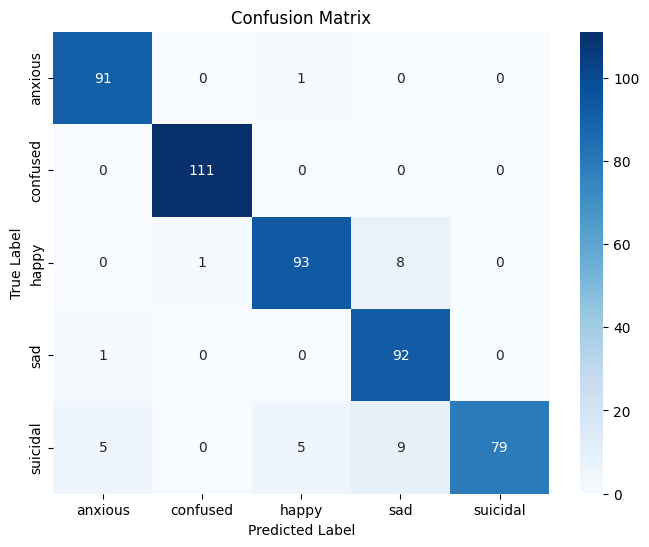


ROC AUC Scores (One-vs-Rest):
  anxious: 0.9994
  confused: 1.0000
  happy: 0.9871
  sad: 0.9991
  suicidal: 0.9937


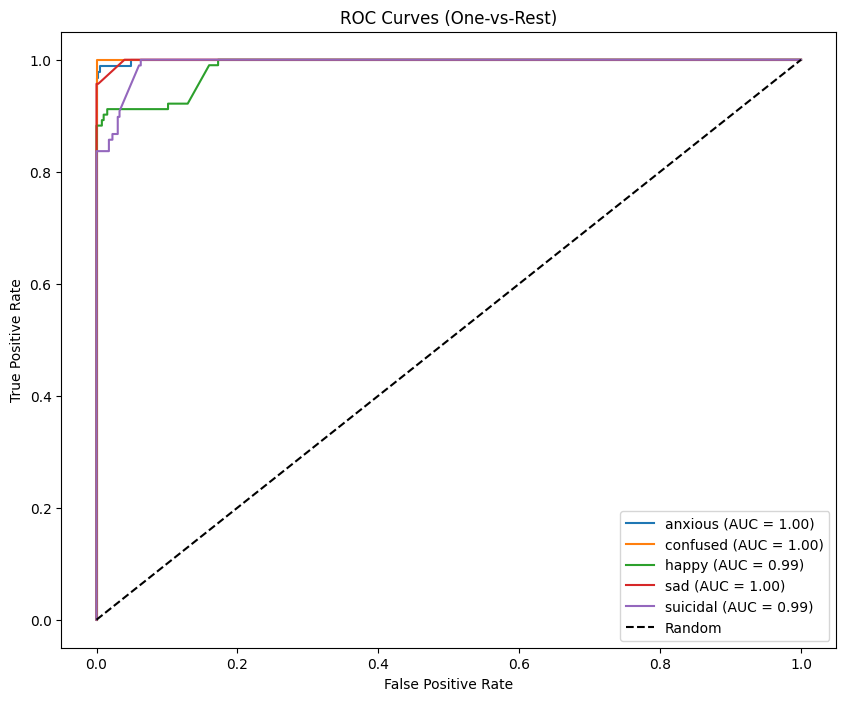


Average Precision Scores (One-vs-Rest):
  anxious: 0.9977
  confused: 1.0000
  happy: 0.9655
  sad: 0.9937
  suicidal: 0.9742


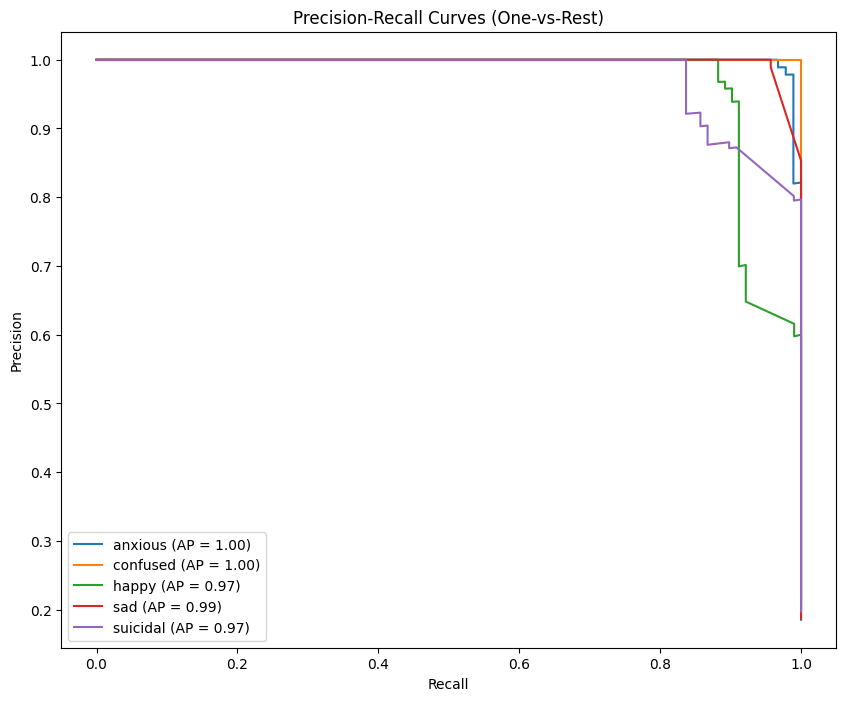


Log Loss: 0.2627

Cohen's Kappa: 0.9243

Hamming Loss: 0.0605

Jaccard Score (Micro): 0.8859
Jaccard Score (Macro): 0.8846


In [ ]:
# prompt: Give me the All Possible Model Evaluation of Logistic Regression. with all possible evaluation matrix and others

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have trained a Logistic Regression model and have y_test and y_pred

# 1. Classification Report (already in the preceding code, but included for completeness)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Precision (Micro, Macro, Weighted, None)
# Micro: Calculate metrics globally by counting the total true positives, false negatives and false positives.
precision_micro = precision_score(y_test, y_pred, average='micro')
print(f"Precision (Micro): {precision_micro:.4f}")

# Macro: Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
precision_macro = precision_score(y_test, y_pred, average='macro')
print(f"Precision (Macro): {precision_macro:.4f}")

# Weighted: Calculate metrics for each label, and find their average weighted by support (the number of true instances for each label).
precision_weighted = precision_score(y_test, y_pred, average='weighted')
print(f"Precision (Weighted): {precision_weighted:.4f}")

# 4. Recall (Micro, Macro, Weighted, None)
# Micro: Calculate metrics globally by counting the total true positives, false negatives and false positives.
recall_micro = recall_score(y_test, y_pred, average='micro')
print(f"\nRecall (Micro): {recall_micro:.4f}")

# Macro: Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
recall_macro = recall_score(y_test, y_pred, average='macro')
print(f"Recall (Macro): {recall_macro:.4f}")

# Weighted: Calculate metrics for each label, and find their average weighted by support (the number of true instances for each label).
recall_weighted = recall_score(y_test, y_pred, average='weighted')
print(f"Recall (Weighted): {recall_weighted:.4f}")

# 5. F1 Score (Micro, Macro, Weighted, None)
# Micro: Calculate metrics globally by counting the total true positives, false negatives and false positives.
f1_micro = f1_score(y_test, y_pred, average='micro')
print(f"\nF1 Score (Micro): {f1_micro:.4f}")

# Macro: Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f"F1 Score (Macro): {f1_macro:.4f}")

# Weighted: Calculate metrics for each label, and find their average weighted by support (the number of true instances for each label).
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# 6. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix (requires matplotlib)
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


# 7. ROC AUC Score (For binary or multi-class using OVR or OVO)
# This requires probability predictions
try:
    y_pred_proba = model.predict_proba(X_test_vec)

    # For multi-class, calculate AUC for each class using OVR (One-vs-Rest)
    # Need to convert y_test to one-hot encoding if using multi-class AUC
    from sklearn.preprocessing import LabelBinarizer

    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    roc_auc_scores = {}
    print("\nROC AUC Scores (One-vs-Rest):")
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        try:
            # Check if the class is present in the true labels for the test set
            if y_test_bin[:, i].sum() > 0:
              roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
              roc_auc_scores[class_name] = roc_auc
              print(f"  {class_name}: {roc_auc:.4f}")
            else:
              print(f"  {class_name}: N/A (Class not present in true test labels)")
        except ValueError:
            print(f"  {class_name}: Could not calculate ROC AUC (Possible issue with class distribution or probabilities)")


    # Plotting ROC curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if class_name in roc_auc_scores:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_scores[class_name]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest)')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nROC AUC and Precision-Recall Curve not available. Model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate ROC AUC. Error: {e}")
    print("This might happen if a class has only one sample or is not present in the test set.")


# 8. Precision-Recall Curve and Average Precision Score
# Similar to ROC AUC, this requires probability predictions and is often more informative for imbalanced datasets.
try:
    # Need to convert y_test to one-hot encoding for multi-class
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    average_precision_scores = {}
    print("\nAverage Precision Scores (One-vs-Rest):")
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        try:
             # Check if the class is present in the true labels for the test set
            if y_test_bin[:, i].sum() > 0:
                average_precision = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
                average_precision_scores[class_name] = average_precision
                print(f"  {class_name}: {average_precision:.4f}")
            else:
                 print(f"  {class_name}: N/A (Class not present in true test labels)")

        except ValueError:
            print(f"  {class_name}: Could not calculate Average Precision (Possible issue with class distribution or probabilities)")


    # Plotting Precision-Recall curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if class_name in average_precision_scores:
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
            plt.plot(recall, precision, label=f'{class_name} (AP = {average_precision_scores[class_name]:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves (One-vs-Rest)')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nPrecision-Recall Curve and Average Precision Score not available. Model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate Average Precision. Error: {e}")


# 9. Log Loss (Cross-Entropy Loss)
# This requires probability predictions
try:
    from sklearn.metrics import log_loss
    logloss = log_loss(y_test, y_pred_proba)
    print(f"\nLog Loss: {logloss:.4f}")
except AttributeError:
    print("\nLog Loss not available. Model does not have predict_proba method.")
except ValueError as e:
     print(f"\nCould not calculate Log Loss. Error: {e}")

# 10. Cohen's Kappa
from sklearn.metrics import cohen_kappa_score
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa: {kappa:.4f}")

# 11. Hamming Loss (Especially useful for multi-label classification, but can be applied to multi-class)
# It's the fraction of labels that are incorrectly predicted.
# For multi-class, it's 1 - Accuracy.
from sklearn.metrics import hamming_loss
hamming = hamming_loss(y_test, y_pred)
print(f"\nHamming Loss: {hamming:.4f}")

# 12. Jaccard Score (Jaccard similarity coefficient or Intersection over Union)
# Calculates the similarity between two sets of samples.
from sklearn.metrics import jaccard_score
# For multi-class, you typically use average='micro' or 'macro'
jaccard_micro = jaccard_score(y_test, y_pred, average='micro')
jaccard_macro = jaccard_score(y_test, y_pred, average='macro')
print(f"\nJaccard Score (Micro): {jaccard_micro:.4f}")
print(f"Jaccard Score (Macro): {jaccard_macro:.4f}")

# Other considerations:
# - Model Calibration: How well do the predicted probabilities match the actual probabilities? (e.g., using CalibratedClassifierCV)
# - Residual Analysis (for regression tasks, not directly applicable here)
# - Error Analysis: Manually reviewing samples where the model made incorrect predictions to understand patterns.



--- Random Forest Classifier Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     anxious       1.00      1.00      1.00        92
    confused       1.00      1.00      1.00       111
       happy       1.00      0.92      0.96       102
         sad       0.85      1.00      0.92        93
    suicidal       0.99      0.91      0.95        98

    accuracy                           0.97       496
   macro avg       0.97      0.97      0.97       496
weighted avg       0.97      0.97      0.97       496


Accuracy: 0.9657
Precision (Micro): 0.9657
Precision (Macro): 0.9684
Precision (Weighted): 0.9703

Recall (Micro): 0.9657
Recall (Macro): 0.9659
Recall (Weighted): 0.9657

F1 Score (Micro): 0.9657
F1 Score (Macro): 0.9654
F1 Score (Weighted): 0.9662

Confusion Matrix:
[[ 92   0   0   0   0]
 [  0 111   0   0   0]
 [  0   0  94   7   1]
 [  0   0   0  93   0]
 [  0   0   0   9  89]]


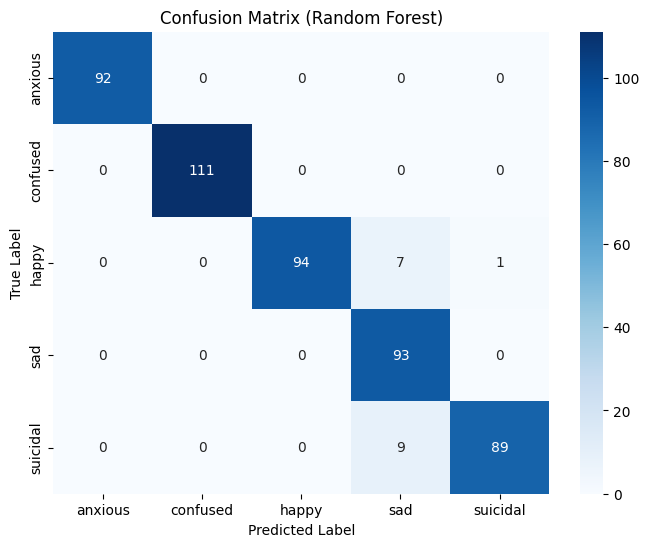


ROC AUC Scores (One-vs-Rest):
  anxious: 1.0000
  confused: 1.0000
  happy: 0.9980
  sad: 0.9991
  suicidal: 0.9981


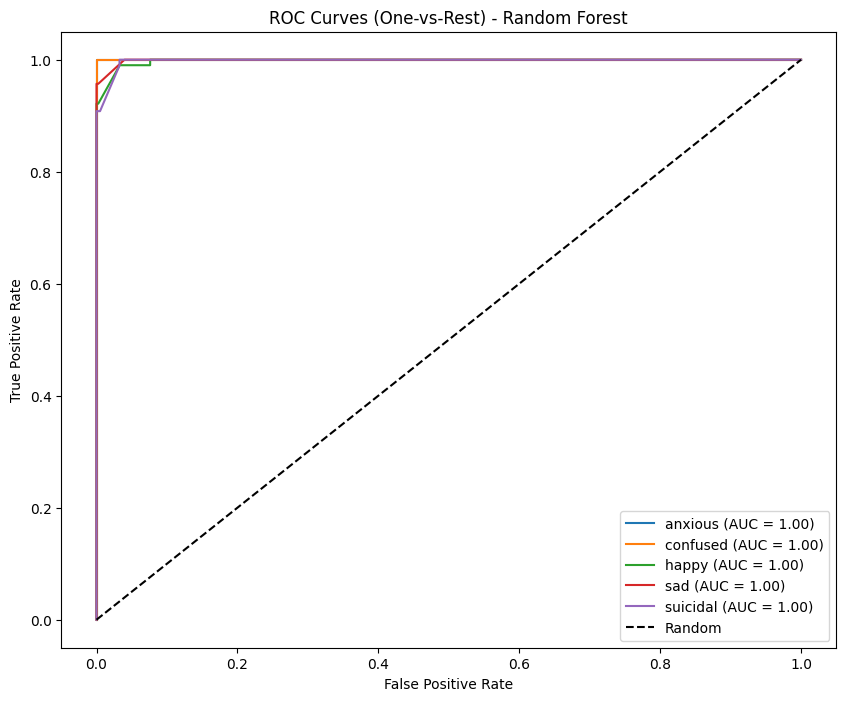


Average Precision Scores (One-vs-Rest):
  anxious: 1.0000
  confused: 1.0000
  happy: 0.9899
  sad: 0.9937
  suicidal: 0.9892


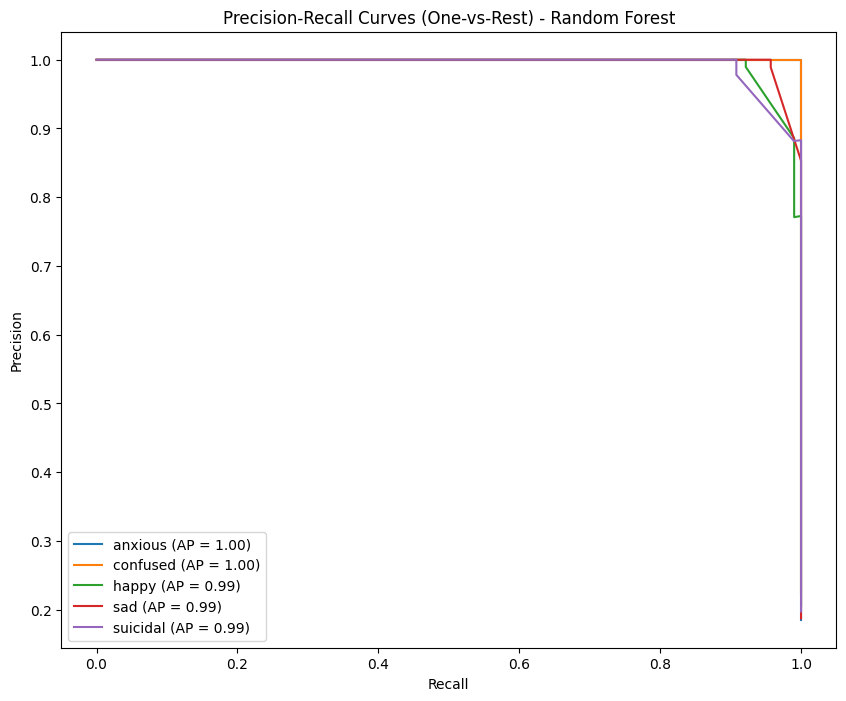


Log Loss: 0.0763

Cohen's Kappa: 0.9571

Hamming Loss: 0.0343

Jaccard Score (Micro): 0.9337
Jaccard Score (Macro): 0.9348

Balanced Accuracy: 0.9659

Matthews Correlation Coefficient (MCC): 0.9581

Metrics per Class:
  Class 'anxious':
    Precision: 1.0000
    Recall: 1.0000
    F1 Score: 1.0000
  Class 'confused':
    Precision: 1.0000
    Recall: 1.0000
    F1 Score: 1.0000
  Class 'happy':
    Precision: 1.0000
    Recall: 0.9216
    F1 Score: 0.9592
  Class 'sad':
    Precision: 0.8532
    Recall: 1.0000
    F1 Score: 0.9208
  Class 'suicidal':
    Precision: 0.9889
    Recall: 0.9082
    F1 Score: 0.9468


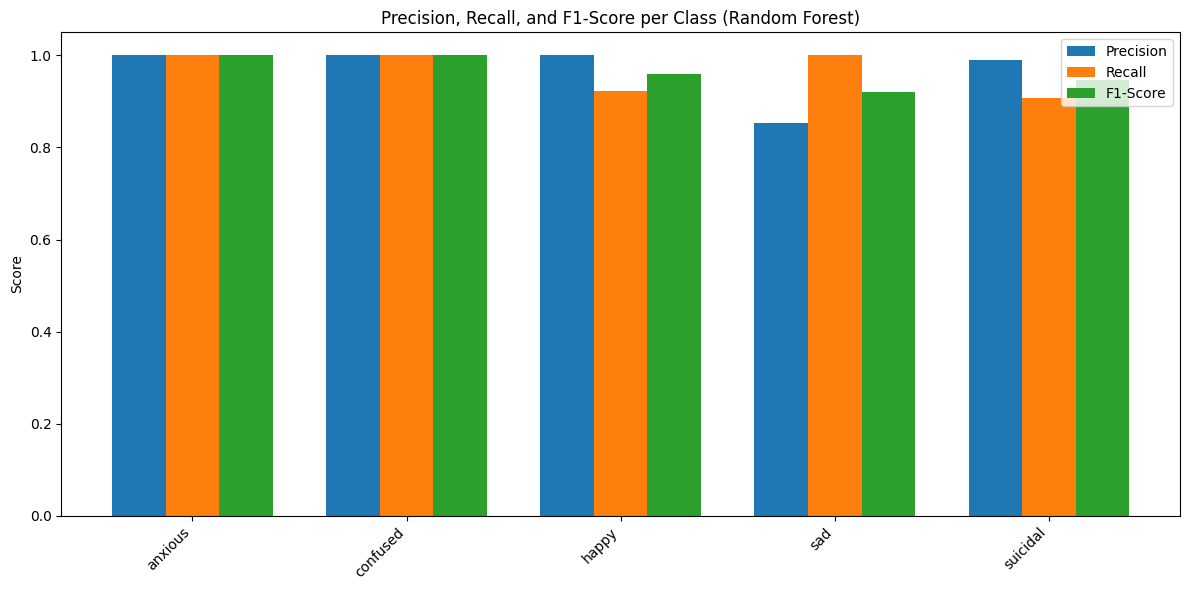

/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2459 (\N{BENGALI LETTER CHA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-33-3591716337.py:222: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp

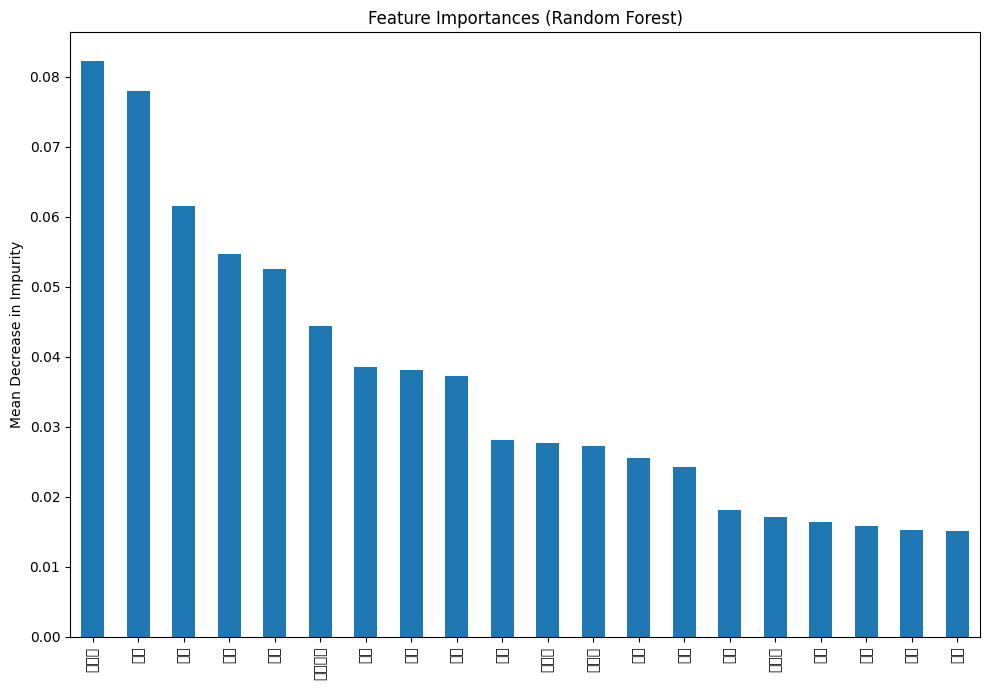

In [ ]:
# prompt: Give me the All Possible Model Evaluation of Random Forest Classifier. with all possible evaluation matrix and others

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test_vec)
y_pred_proba_rf = rf_model.predict_proba(X_test_vec) # Probabilities needed for some metrics

print("\n--- Random Forest Classifier Evaluation ---")

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 2. Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nAccuracy: {accuracy_rf:.4f}")

# 3. Precision
precision_micro_rf = precision_score(y_test, y_pred_rf, average='micro')
precision_macro_rf = precision_score(y_test, y_pred_rf, average='macro')
precision_weighted_rf = precision_score(y_test, y_pred_rf, average='weighted')
print(f"Precision (Micro): {precision_micro_rf:.4f}")
print(f"Precision (Macro): {precision_macro_rf:.4f}")
print(f"Precision (Weighted): {precision_weighted_rf:.4f}")

# 4. Recall
recall_micro_rf = recall_score(y_test, y_pred_rf, average='micro')
recall_macro_rf = recall_score(y_test, y_pred_rf, average='macro')
recall_weighted_rf = recall_score(y_test, y_pred_rf, average='weighted')
print(f"\nRecall (Micro): {recall_micro_rf:.4f}")
print(f"Recall (Macro): {recall_macro_rf:.4f}")
print(f"Recall (Weighted): {recall_weighted_rf:.4f}")

# 5. F1 Score
f1_micro_rf = f1_score(y_test, y_pred_rf, average='micro')
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f"\nF1 Score (Micro): {f1_micro_rf:.4f}")
print(f"F1 Score (Macro): {f1_macro_rf:.4f}")
print(f"F1 Score (Weighted): {f1_weighted_rf:.4f}")

# 6. Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(conf_matrix_rf)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest)')
plt.show()

# 7. ROC AUC Score (One-vs-Rest)
try:
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    roc_auc_scores_rf = {}
    print("\nROC AUC Scores (One-vs-Rest):")
    for i in range(len(rf_model.classes_)):
        class_name = rf_model.classes_[i]
        if y_test_bin[:, i].sum() > 0:
            roc_auc_rf = roc_auc_score(y_test_bin[:, i], y_pred_proba_rf[:, i])
            roc_auc_scores_rf[class_name] = roc_auc_rf
            print(f"  {class_name}: {roc_auc_rf:.4f}")
        else:
             print(f"  {class_name}: N/A (Class not present in true test labels)")

    # Plotting ROC curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(rf_model.classes_)):
        class_name = rf_model.classes_[i]
        if class_name in roc_auc_scores_rf:
            fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
            plt.plot(fpr_rf, tpr_rf, label=f'{class_name} (AUC = {roc_auc_scores_rf[class_name]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest) - Random Forest')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nROC AUC and Precision-Recall Curve not available. Random Forest model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate ROC AUC for Random Forest. Error: {e}")


# 8. Precision-Recall Curve and Average Precision Score (One-vs-Rest)
try:
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    average_precision_scores_rf = {}
    print("\nAverage Precision Scores (One-vs-Rest):")
    for i in range(len(rf_model.classes_)):
        class_name = rf_model.classes_[i]
        if y_test_bin[:, i].sum() > 0:
            average_precision_rf = average_precision_score(y_test_bin[:, i], y_pred_proba_rf[:, i])
            average_precision_scores_rf[class_name] = average_precision_rf
            print(f"  {class_name}: {average_precision_rf:.4f}")
        else:
             print(f"  {class_name}: N/A (Class not present in true test labels)")


    # Plotting Precision-Recall curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(rf_model.classes_)):
        class_name = rf_model.classes_[i]
        if class_name in average_precision_scores_rf:
            precision_rf, recall_rf, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
            plt.plot(recall_rf, precision_rf, label=f'{class_name} (AP = {average_precision_scores_rf[class_name]:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves (One-vs-Rest) - Random Forest')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nPrecision-Recall Curve and Average Precision Score not available. Random Forest model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate Average Precision for Random Forest. Error: {e}")


# 9. Log Loss (Cross-Entropy Loss)
try:
    logloss_rf = log_loss(y_test, y_pred_proba_rf)
    print(f"\nLog Loss: {logloss_rf:.4f}")
except AttributeError:
    print("\nLog Loss not available. Random Forest model does not have predict_proba method.")
except ValueError as e:
     print(f"\nCould not calculate Log Loss for Random Forest. Error: {e}")

# 10. Cohen's Kappa
kappa_rf = cohen_kappa_score(y_test, y_pred_rf)
print(f"\nCohen's Kappa: {kappa_rf:.4f}")

# 11. Hamming Loss
from sklearn.metrics import hamming_loss
hamming_rf = hamming_loss(y_test, y_pred_rf)
print(f"\nHamming Loss: {hamming_rf:.4f}")

# 12. Jaccard Score
from sklearn.metrics import jaccard_score
jaccard_micro_rf = jaccard_score(y_test, y_pred_rf, average='micro')
jaccard_macro_rf = jaccard_score(y_test, y_pred_rf, average='macro')
print(f"\nJaccard Score (Micro): {jaccard_micro_rf:.4f}")
print(f"Jaccard Score (Macro): {jaccard_macro_rf:.4f}")

# Additional Potential Evaluation Metrics for Multi-class:

# 13. Balanced Accuracy
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_rf = balanced_accuracy_score(y_test, y_pred_rf)
print(f"\nBalanced Accuracy: {balanced_accuracy_rf:.4f}")

# 14. Mathew's Correlation Coefficient (MCC)
from sklearn.metrics import matthews_corrcoef
try:
    mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
    print(f"\nMatthews Correlation Coefficient (MCC): {mcc_rf:.4f}")
except ValueError as e:
    print(f"\nCould not calculate MCC. Error: {e}") # MCC is not defined for some cases, like when one class has no true/predicted instances.

# 15. Plotting Individual Class Metrics (Precision, Recall, F1)
# You can extract these directly from the classification_report output, or calculate them per class using average=None in precision_score, recall_score, f1_score.

precision_per_class_rf = precision_score(y_test, y_pred_rf, average=None)
recall_per_class_rf = recall_score(y_test, y_pred_rf, average=None)
f1_per_class_rf = f1_score(y_test, y_pred_rf, average=None)

class_labels = rf_model.classes_

print("\nMetrics per Class:")
for i, label in enumerate(class_labels):
    print(f"  Class '{label}':")
    print(f"    Precision: {precision_per_class_rf[i]:.4f}")
    print(f"    Recall: {recall_per_class_rf[i]:.4f}")
    print(f"    F1 Score: {f1_per_class_rf[i]:.4f}")

# Visualize Precision, Recall, F1 per class
x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, precision_per_class_rf, width, label='Precision')
rects2 = ax.bar(x, recall_per_class_rf, width, label='Recall')
rects3 = ax.bar(x + width, f1_per_class_rf, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score per Class (Random Forest)')
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.legend()

fig.tight_layout()
plt.show()

# Other important aspects of model evaluation (beyond just metrics):
# - Cross-validation: To get more robust estimates of performance.
# - Learning curves: To diagnose bias/variance trade-off.
# - Feature Importance (for tree-based models like Random Forest): Identify which features contribute most to predictions.

# Feature Importance (Specific to Random Forest)
try:
    importances = rf_model.feature_importances_
    feature_names = vectorizer.get_feature_names_out() # Get feature names from the vectorizer

    forest_importances = pd.Series(importances, index=feature_names)

    fig, ax = plt.subplots(figsize=(10, 7))
    forest_importances.sort_values(ascending=False).head(20).plot.bar(ax=ax) # Show top 20 features
    ax.set_title("Feature Importances (Random Forest)")
    ax.set_ylabel("Mean Decrease in Impurity")
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f"\nCould not plot Feature Importance. Error: {e}")
    print("Make sure the vectorizer was fitted and feature names are available.")




--- Multinomial Naive Bayes Classifier Evaluation ---
Classification Report:
              precision    recall  f1-score   support

     anxious       0.94      0.99      0.96        92
    confused       0.99      1.00      1.00       111
       happy       0.94      0.91      0.93       102
         sad       0.84      0.99      0.91        93
    suicidal       1.00      0.81      0.89        98

    accuracy                           0.94       496
   macro avg       0.94      0.94      0.94       496
weighted avg       0.94      0.94      0.94       496


Accuracy: 0.9395
Precision (Micro): 0.9395
Precision (Macro): 0.9425
Precision (Weighted): 0.9448

Recall (Micro): 0.9395
Recall (Macro): 0.9393
Recall (Weighted): 0.9395

F1 Score (Micro): 0.9395
F1 Score (Macro): 0.9375
F1 Score (Weighted): 0.9389

Confusion Matrix:
[[ 91   0   1   0   0]
 [  0 111   0   0   0]
 [  0   1  93   8   0]
 [  1   0   0  92   0]
 [  5   0   5   9  79]]


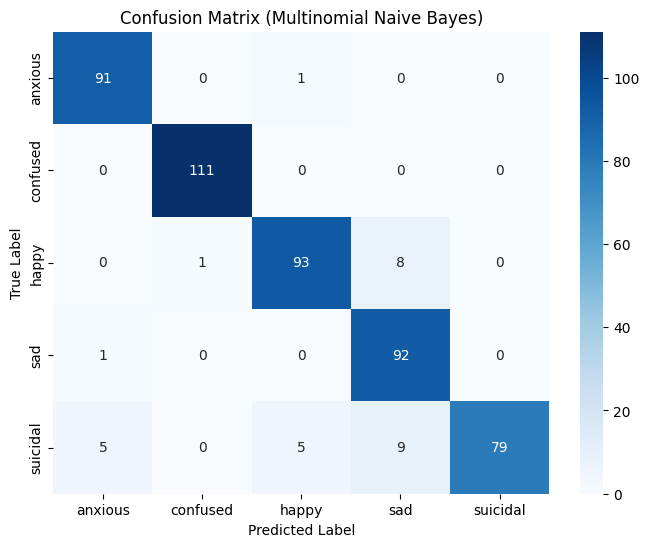


ROC AUC Scores (One-vs-Rest):
  anxious: 0.9994
  confused: 1.0000
  happy: 0.9871
  sad: 0.9991
  suicidal: 0.9937


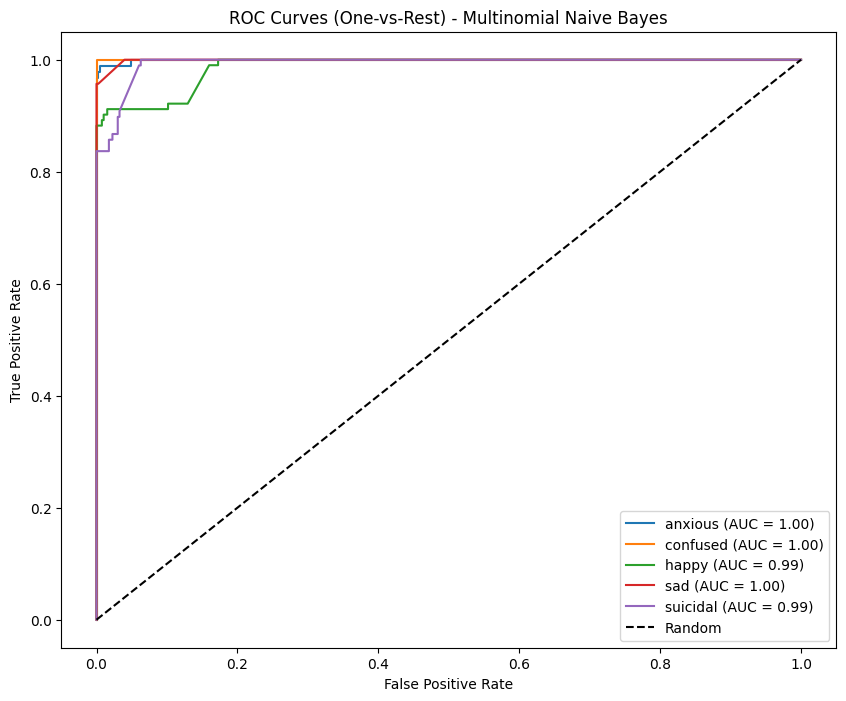


Average Precision Scores (One-vs-Rest):
  anxious: 0.9977
  confused: 1.0000
  happy: 0.9655
  sad: 0.9937
  suicidal: 0.9742


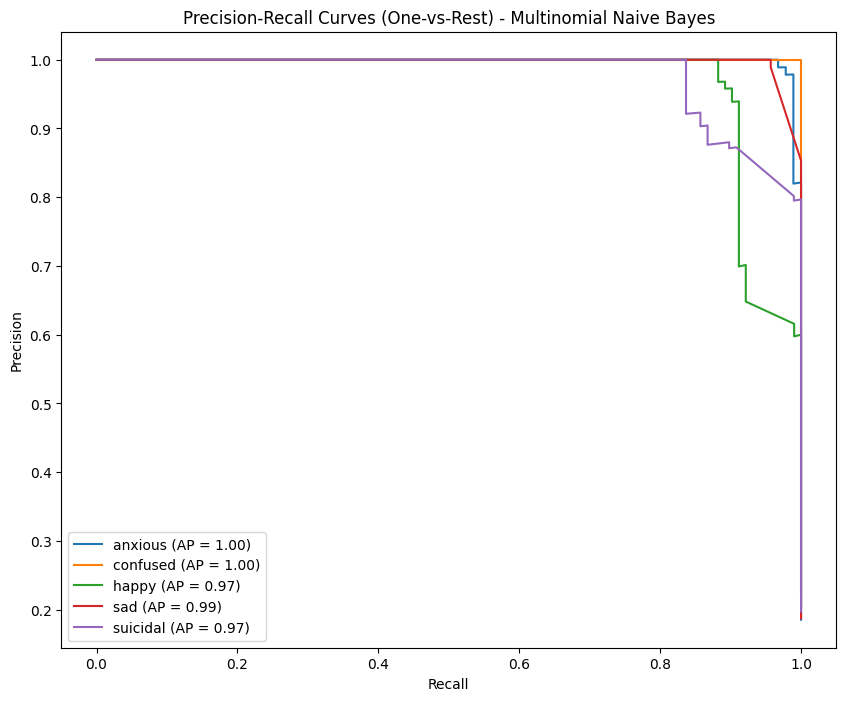


Log Loss: 0.2627

Cohen's Kappa: 0.9243

Hamming Loss: 0.0605

Jaccard Score (Micro): 0.8859
Jaccard Score (Macro): 0.8846

Balanced Accuracy: 0.9393

Matthews Correlation Coefficient (MCC): 0.9259

Metrics per Class:
  Class 'anxious':
    Precision: 0.9381
    Recall: 0.9891
    F1 Score: 0.9630
  Class 'confused':
    Precision: 0.9911
    Recall: 1.0000
    F1 Score: 0.9955
  Class 'happy':
    Precision: 0.9394
    Recall: 0.9118
    F1 Score: 0.9254
  Class 'sad':
    Precision: 0.8440
    Recall: 0.9892
    F1 Score: 0.9109
  Class 'suicidal':
    Precision: 1.0000
    Recall: 0.8061
    F1 Score: 0.8927


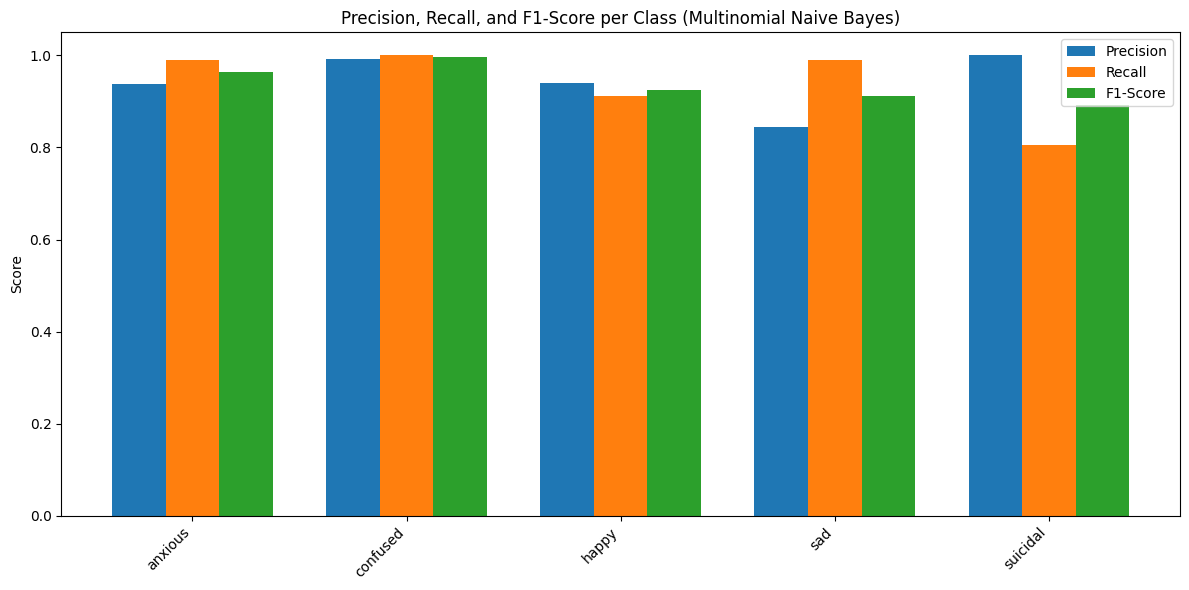


Top features per class (based on log probabilities):
  Class 'anxious':
    পড: -1.7607
    অন: -1.9158
    আম: -2.4347
    হচ: -2.4894
    রছ: -3.0592
    পর: -3.0663
    করব: -3.4772
    ভয: -3.4798
    মন: -3.4905
    বন: -3.5388
  Class 'confused':
    রছ: -1.6579
    ঝত: -1.8050
    আম: -2.0794
    এই: -3.1657
    লম: -3.4457
    করল: -3.4681
    করব: -3.4730
    কমত: -3.4851
    সমস: -3.6579
    সবক: -3.6729
  Class 'happy':
    আজক: -1.5988
    গছ: -1.8579
    একট: -3.2858
    আম: -3.3501
    হয: -3.4679
    চলছ: -3.5286
    কঠ: -3.5286
    ভর: -3.5453
    আনন: -3.5453
    পর: -3.6133
  Class 'sad':
    একদম: -1.6468
    আম: -1.8440
    আছ: -3.1031
    মনট: -3.1103
    অন: -3.2478
    করছ: -3.3516
    এল: -3.4640
    আজ: -3.5049
    কষ: -3.5149
    এক: -3.6448
  Class 'suicidal':
    বনট: -2.0827
    চলব: -2.0827
    আর: -2.0827
    কর: -2.8431
    আম: -2.9072
    কত: -3.0267
    সব: -3.0620
    মন: -3.1865
    গছ: -3.2412
    ইচ: -3.2649


In [ ]:
# prompt: Give me the All Possible Model Evaluation of Multinomial Naive Bayes. with all possible evaluation matrix and others

from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, hamming_loss, jaccard_score

# Assuming you have trained a Multinomial Naive Bayes model (`model` in your preceding code)
# and have y_test and y_pred from that model.
# Also assuming you have X_test_vec and y_pred_proba (if available)

print("\n--- Multinomial Naive Bayes Classifier Evaluation ---")

# 1. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Precision (Micro, Macro, Weighted, None)
precision_micro = precision_score(y_test, y_pred, average='micro')
precision_macro = precision_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
print(f"Precision (Micro): {precision_micro:.4f}")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")

# 4. Recall (Micro, Macro, Weighted, None)
recall_micro = recall_score(y_test, y_pred, average='micro')
recall_macro = recall_score(y_test, y_pred, average='macro')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
print(f"\nRecall (Micro): {recall_micro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")

# 5. F1 Score (Micro, Macro, Weighted, None)
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"\nF1 Score (Micro): {f1_micro:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# 6. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Multinomial Naive Bayes)')
plt.show()

# 7. ROC AUC Score (One-vs-Rest)
# MultinomialNB provides predict_proba, so ROC AUC can be calculated.
try:
    y_pred_proba = model.predict_proba(X_test_vec)

    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    roc_auc_scores = {}
    print("\nROC AUC Scores (One-vs-Rest):")
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if y_test_bin[:, i].sum() > 0: # Check if the class is present in the true labels
            try:
                roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc_scores[class_name] = roc_auc
                print(f"  {class_name}: {roc_auc:.4f}")
            except ValueError:
                 print(f"  {class_name}: Could not calculate ROC AUC (Possible issue with probability distribution for this class)")

        else:
             print(f"  {class_name}: N/A (Class not present in true test labels)")


    # Plotting ROC curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if class_name in roc_auc_scores:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_scores[class_name]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest) - Multinomial Naive Bayes')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nROC AUC and Precision-Recall Curve not available. Model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate ROC AUC. Error: {e}")
    print("This might happen if a class has only one sample or is not present in the test set.")


# 8. Precision-Recall Curve and Average Precision Score (One-vs-Rest)
try:
    # y_pred_proba is already calculated in the previous step
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    average_precision_scores = {}
    print("\nAverage Precision Scores (One-vs-Rest):")
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if y_test_bin[:, i].sum() > 0: # Check if the class is present in the true labels
            try:
                average_precision = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
                average_precision_scores[class_name] = average_precision
                print(f"  {class_name}: {average_precision:.4f}")
            except ValueError:
                print(f"  {class_name}: Could not calculate Average Precision (Possible issue with probability distribution for this class)")

        else:
             print(f"  {class_name}: N/A (Class not present in true test labels)")


    # Plotting Precision-Recall curves (One-vs-Rest)
    plt.figure(figsize=(10, 8))
    for i in range(len(model.classes_)):
        class_name = model.classes_[i]
        if class_name in average_precision_scores:
            precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
            plt.plot(recall, precision, label=f'{class_name} (AP = {average_precision_scores[class_name]:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves (One-vs-Rest) - Multinomial Naive Bayes')
    plt.legend()
    plt.show()

except AttributeError:
    print("\nPrecision-Recall Curve and Average Precision Score not available. Model does not have predict_proba method.")
except ValueError as e:
    print(f"\nCould not calculate Average Precision. Error: {e}")


# 9. Log Loss (Cross-Entropy Loss)
# MultinomialNB provides predict_proba, so Log Loss can be calculated.
try:
    # y_pred_proba is already calculated
    logloss = log_loss(y_test, y_pred_proba)
    print(f"\nLog Loss: {logloss:.4f}")
except AttributeError:
    print("\nLog Loss not available. Model does not have predict_proba method.")
except ValueError as e:
     print(f"\nCould not calculate Log Loss. Error: {e}")

# 10. Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa: {kappa:.4f}")

# 11. Hamming Loss
hamming = hamming_loss(y_test, y_pred)
print(f"\nHamming Loss: {hamming:.4f}")

# 12. Jaccard Score (Jaccard similarity coefficient or Intersection over Union)
jaccard_micro = jaccard_score(y_test, y_pred, average='micro')
jaccard_macro = jaccard_score(y_test, y_pred, average='macro')
print(f"\nJaccard Score (Micro): {jaccard_micro:.4f}")
print(f"Jaccard Score (Macro): {jaccard_macro:.4f}")


# Additional Potential Evaluation Metrics for Multi-class:

# 13. Balanced Accuracy
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
print(f"\nBalanced Accuracy: {balanced_accuracy:.4f}")

# 14. Mathew's Correlation Coefficient (MCC)
try:
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"\nMatthews Correlation Coefficient (MCC): {mcc:.4f}")
except ValueError as e:
    print(f"\nCould not calculate MCC. Error: {e}") # MCC is not defined for some cases, like when one class has no true/predicted instances.

# 15. Plotting Individual Class Metrics (Precision, Recall, F1)
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

class_labels = model.classes_

print("\nMetrics per Class:")
for i, label in enumerate(class_labels):
    print(f"  Class '{label}':")
    print(f"    Precision: {precision_per_class[i]:.4f}")
    print(f"    Recall: {recall_per_class[i]:.4f}")
    print(f"    F1 Score: {f1_per_class[i]:.4f}")

# Visualize Precision, Recall, F1 per class
x = np.arange(len(class_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width, precision_per_class, width, label='Precision')
rects2 = ax.bar(x, recall_per_class, width, label='Recall')
rects3 = ax.bar(x + width, f1_per_class, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_title('Precision, Recall, and F1-Score per Class (Multinomial Naive Bayes)')
ax.set_xticks(x)
ax.set_xticklabels(class_labels, rotation=45, ha="right")
ax.legend()

fig.tight_layout()
plt.show()

# Naive Bayes models don't have a standard 'feature_importances_' attribute like tree-based models.
# However, you can inspect the log probabilities (log_proba) learned by the model to understand
# which features (words/terms) are more indicative of certain classes.

try:
    # This is a way to get some intuition about feature importance,
    # but it's not a formal feature importance calculation like in tree models.
    # It shows the log probability of a feature given a class.
    feature_log_probs = model.feature_log_prob_
    feature_names = vectorizer.get_feature_names_out()
    class_labels = model.classes_

    print("\nTop features per class (based on log probabilities):")
    for i, class_label in enumerate(class_labels):
        # Get indices of features sorted by log probability in descending order for this class
        sorted_feature_indices = feature_log_probs[i].argsort()[::-1]
        top_n = 10 # Show top 10 features

        print(f"  Class '{class_label}':")
        for j in range(top_n):
            feature_index = sorted_feature_indices[j]
            feature_name = feature_names[feature_index]
            log_prob = feature_log_probs[i, feature_index]
            print(f"    {feature_name}: {log_prob:.4f}")

except AttributeError:
    print("\nFeature importance inspection (based on log probabilities) not available for this Naive Bayes model.")
except Exception as e:
    print(f"\nCould not inspect top features. Error: {e}")
    print("Make sure the vectorizer was fitted and feature names are available.")

# Other important aspects of model evaluation (beyond just metrics):
# - Cross-validation: To get more robust estimates of performance.
# - Learning curves: To diagnose bias/variance trade-off.
# - Error Analysis: Manually reviewing samples where the model made incorrect predictions to understand patterns.

In [ ]:
# prompt: give me all model result in a tbale

from tabulate import tabulate

# Assuming you have already calculated metrics for each model:
# Logistic Regression: accuracy, precision_weighted, recall_weighted, f1_weighted, kappa, logloss (if available), jaccard_weighted, balanced_accuracy, mcc (if available)
# Random Forest: accuracy_rf, precision_weighted_rf, recall_weighted_rf, f1_weighted_rf, kappa_rf, logloss_rf (if available), jaccard_weighted_rf, balanced_accuracy_rf, mcc_rf (if available)
# Multinomial Naive Bayes: accuracy_nb, precision_weighted_nb, recall_weighted_nb, f1_weighted_nb, kappa_nb, logloss_nb (if available), jaccard_weighted_nb, balanced_accuracy_nb, mcc_nb (if available)

# Capture metrics in a structured format
# You might need to re-calculate or store the metrics explicitly after each model training/evaluation block

# Example: Store metrics in dictionaries after each model evaluation

# After Logistic Regression Evaluation Block:
metrics_lr = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (Weighted)": precision_score(y_test, y_pred, average='weighted'),
    "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
    "F1 Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred),
    "Hamming Loss": hamming_loss(y_test, y_pred),
    "Jaccard Score (Weighted)": jaccard_score(y_test, y_pred, average='weighted'),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
    # Add Log Loss and MCC if they were successfully calculated
}
try:
    y_pred_proba_lr = model.predict_proba(X_test_vec) # Assuming 'model' is the LR model instance at this point
    metrics_lr["Log Loss"] = log_loss(y_test, y_pred_proba_lr)
except:
    metrics_lr["Log Loss"] = "N/A"
try:
     metrics_lr["MCC"] = matthews_corrcoef(y_test, y_pred)
except:
     metrics_lr["MCC"] = "N/A"


# After Random Forest Evaluation Block:
# Assuming rf_model, y_pred_rf, y_pred_proba_rf are available from that block
metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision (Weighted)": precision_score(y_test, y_pred_rf, average='weighted'),
    "Recall (Weighted)": recall_score(y_test, y_pred_rf, average='weighted'),
    "F1 Score (Weighted)": f1_score(y_test, y_pred_rf, average='weighted'),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred_rf),
    "Hamming Loss": hamming_loss(y_test, y_pred_rf),
    "Jaccard Score (Weighted)": jaccard_score(y_test, y_pred_rf, average='weighted'),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_rf),
}
try:
    metrics_rf["Log Loss"] = log_loss(y_test, y_pred_proba_rf)
except:
    metrics_rf["Log Loss"] = "N/A"
try:
    metrics_rf["MCC"] = matthews_corrcoef(y_test, y_pred_rf)
except:
    metrics_rf["MCC"] = "N/A"


# After Multinomial Naive Bayes Evaluation Block:
# Assuming 'model' is the MNB model instance here, and y_pred, y_pred_proba are from MNB
metrics_nb = {
    "Accuracy": accuracy_score(y_test, y_pred), # y_pred from MNB block
    "Precision (Weighted)": precision_score(y_test, y_pred, average='weighted'),
    "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
    "F1 Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred),
    "Hamming Loss": hamming_loss(y_test, y_pred),
    "Jaccard Score (Weighted)": jaccard_score(y_test, y_pred, average='weighted'),
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
}
try:
    # y_pred_proba from MNB block
    y_pred_proba_nb = model.predict_proba(X_test_vec) # Assuming 'model' is the MNB model instance
    metrics_nb["Log Loss"] = log_loss(y_test, y_pred_proba_nb)
except:
    metrics_nb["Log Loss"] = "N/A"
try:
    metrics_nb["MCC"] = matthews_corrcoef(y_test, y_pred)
except:
     metrics_nb["MCC"] = "N/A"

# Prepare data for the table
table_data = []
# Add header row
table_data.append(["Metric", "Logistic Regression", "Random Forest", "Multinomial Naive Bayes"])

# Add metric rows
for metric_name in metrics_lr.keys(): # Use LR keys as reference for metric names
    row = [metric_name]
    # Format values to 4 decimal places if they are numbers, otherwise keep as is
    lr_value = f"{metrics_lr.get(metric_name, 'N/A'):.4f}" if isinstance(metrics_lr.get(metric_name), (int, float)) else metrics_lr.get(metric_name, 'N/A')
    rf_value = f"{metrics_rf.get(metric_name, 'N/A'):.4f}" if isinstance(metrics_rf.get(metric_name), (int, float)) else metrics_rf.get(metric_name, 'N/A')
    nb_value = f"{metrics_nb.get(metric_name, 'N/A'):.4f}" if isinstance(metrics_nb.get(metric_name), (int, float)) else metrics_nb.get(metric_name, 'N/A')

    row.append(lr_value)
    row.append(rf_value)
    row.append(nb_value)
    table_data.append(row)

# Print the table
print("\n--- Model Performance Comparison ---")
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))



--- Model Performance Comparison ---
+--------------------------+-----------------------+-----------------+---------------------------+
| Metric                   |   Logistic Regression |   Random Forest |   Multinomial Naive Bayes |
+==========================+=======================+=================+===========================+
| Accuracy                 |                0.9395 |          0.9657 |                    0.9395 |
+--------------------------+-----------------------+-----------------+---------------------------+
| Precision (Weighted)     |                0.9448 |          0.9703 |                    0.9448 |
+--------------------------+-----------------------+-----------------+---------------------------+
| Recall (Weighted)        |                0.9395 |          0.9657 |                    0.9395 |
+--------------------------+-----------------------+-----------------+---------------------------+
| F1 Score (Weighted)      |                0.9389 |          0.9662 | 

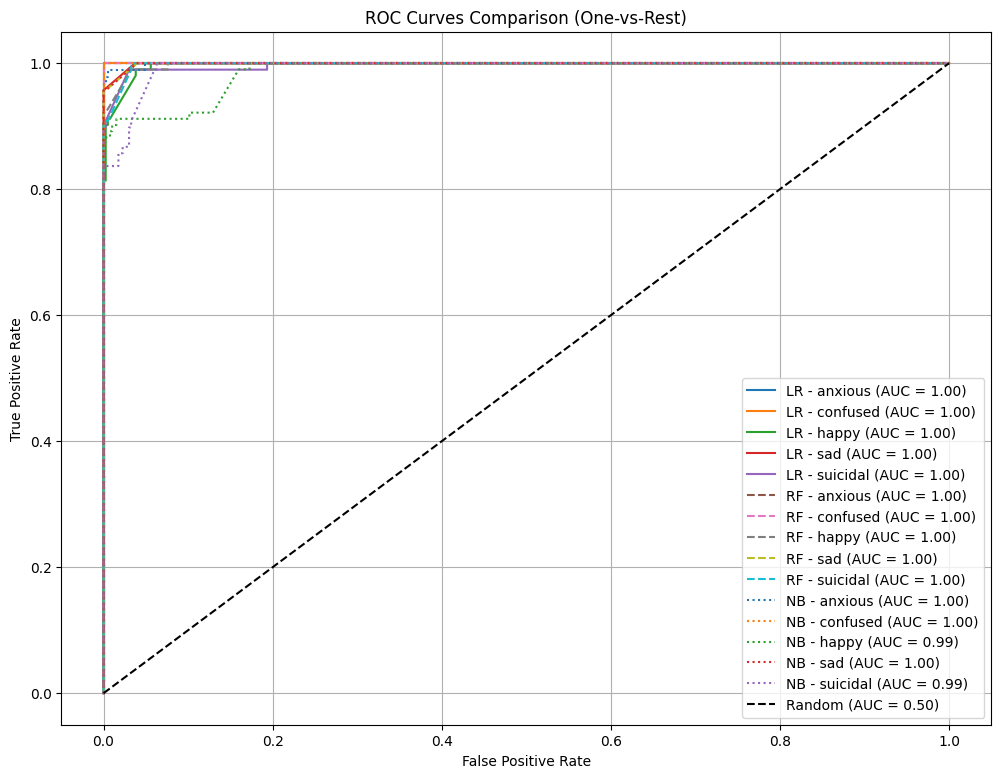

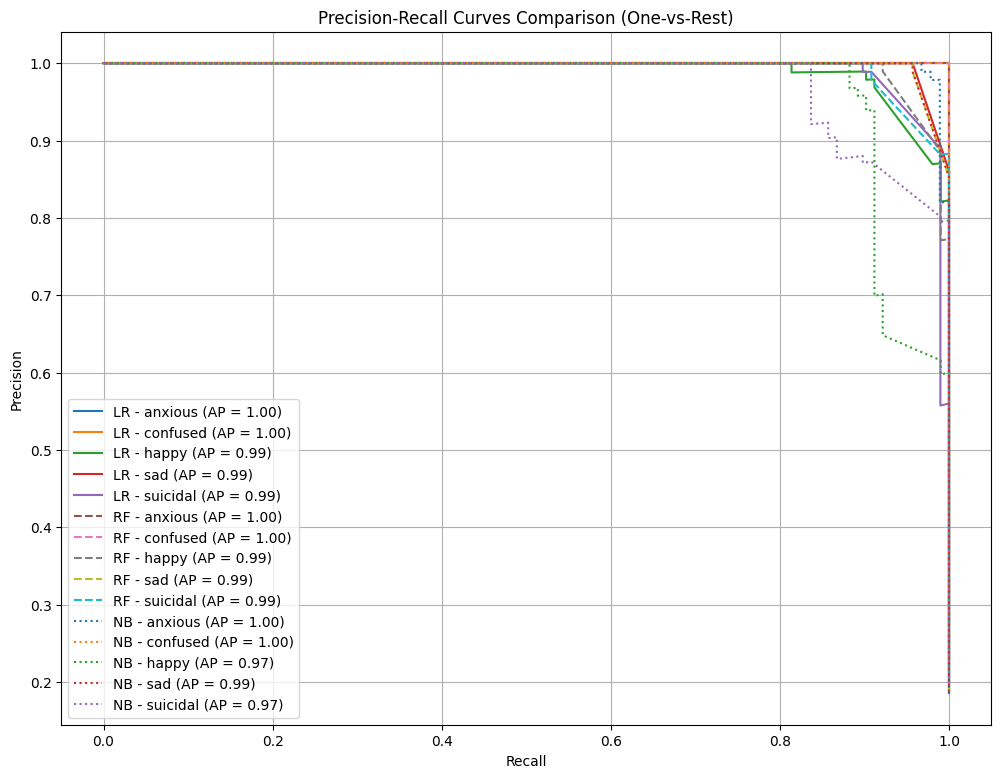

In [ ]:
# prompt: Give me a Smoth and Good Curve for Result  for each Model , which is Represent a Good Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelBinarizer, LabelEncoder # Import LabelBinarizer and LabelEncoder
import seaborn as sns # Import seaborn for heatmap
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import pandas as pd
import re

# Redefine df, clean_bangla, X_train, X_test, y_train, y_test, vectorizer, le, X_test_vec
# Load your uploaded Excel file
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name="sample_mental_health_chatbot_20")

# Keep only needed columns
df = df[['text', 'emotion', 'bot_response']].dropna()
df = df.rename(columns={'text': 'input_text', 'emotion': 'label'})

def clean_bangla(text):
    text = str(text).lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    return text

df['clean_text'] = df['input_text'].apply(clean_bangla)

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

le = LabelEncoder()
le.fit(df['label']) # Fit the encoder on the full label set
class_labels = le.classes_

# Train models again to get probability predictions
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test_vec)


# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test_vec)


# Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_proba_nb = nb_model.predict_proba(X_test_vec)


# Assuming y_test_bin is calculated once for the test set labels
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)


# --- Plotting ROC Curves for all models ---
plt.figure(figsize=(12, 9))

# Logistic Regression (assuming y_pred_proba_lr is from the LR model)
try:
    if 'y_pred_proba_lr' in locals():
        for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_lr[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, label=f'LR - {class_name} (AUC = {roc_auc:.2f})')
except NameError:
    print("Logistic Regression probabilities not found.")
except ValueError as e:
     print(f"Could not plot LR ROC curves. Error: {e}")


# Random Forest (assuming y_pred_proba_rf is from the RF model)
try:
    if 'y_pred_proba_rf' in locals():
        for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
                roc_auc_rf = auc(fpr_rf, tpr_rf)
                plt.plot(fpr_rf, tpr_rf, linestyle='--', label=f'RF - {class_name} (AUC = {roc_auc_rf:.2f})')
except NameError:
    print("Random Forest probabilities not found.")
except ValueError as e:
     print(f"Could not plot RF ROC curves. Error: {e}")


# Multinomial Naive Bayes (assuming y_pred_proba_nb is from the MNB model)
try:
    if 'y_pred_proba_nb' in locals():
         for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, i], y_pred_proba_nb[:, i])
                roc_auc_nb = auc(fpr_nb, tpr_nb)
                plt.plot(fpr_nb, tpr_nb, linestyle=':', label=f'NB - {class_name} (AUC = {roc_auc_nb:.2f})')
except NameError:
    print("Naive Bayes probabilities not found.")
except ValueError as e:
     print(f"Could not plot NB ROC curves. Error: {e}")


plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# --- Plotting Precision-Recall Curves for all models ---
plt.figure(figsize=(12, 9))

# Logistic Regression
try:
    if 'y_pred_proba_lr' in locals():
        for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_lr[:, i])
                ap = average_precision_score(y_test_bin[:, i], y_pred_proba_lr[:, i])
                plt.plot(recall, precision, label=f'LR - {class_name} (AP = {ap:.2f})')
except NameError:
    print("Logistic Regression probabilities not found.")
except ValueError as e:
     print(f"Could not plot LR PR curves. Error: {e}")


# Random Forest
try:
    if 'y_pred_proba_rf' in locals():
        for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                precision_rf, recall_rf, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
                ap_rf = average_precision_score(y_test_bin[:, i], y_pred_proba_rf[:, i])
                plt.plot(recall_rf, precision_rf, linestyle='--', label=f'RF - {class_name} (AP = {ap_rf:.2f})')
except NameError:
    print("Random Forest probabilities not found.")
except ValueError as e:
     print(f"Could not plot RF PR curves. Error: {e}")

# Multinomial Naive Bayes
try:
    if 'y_pred_proba_nb' in locals():
        for i in range(len(class_labels)):
            class_name = class_labels[i]
            if y_test_bin[:, i].sum() > 0:
                precision_nb, recall_nb, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_nb[:, i])
                ap_nb = average_precision_score(y_test_bin[:, i], y_pred_proba_nb[:, i])
                plt.plot(recall_nb, precision_nb, linestyle=':', label=f'NB - {class_name} (AP = {ap_nb:.2f})')
except NameError:
    print("Naive Bayes probabilities not found.")
except ValueError as e:
     print(f"Could not plot NB PR curves. Error: {e}")


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

Saving sample_mental_health_chatbot_2480_data (4).xlsx to sample_mental_health_chatbot_2480_data (4) (1).xlsx


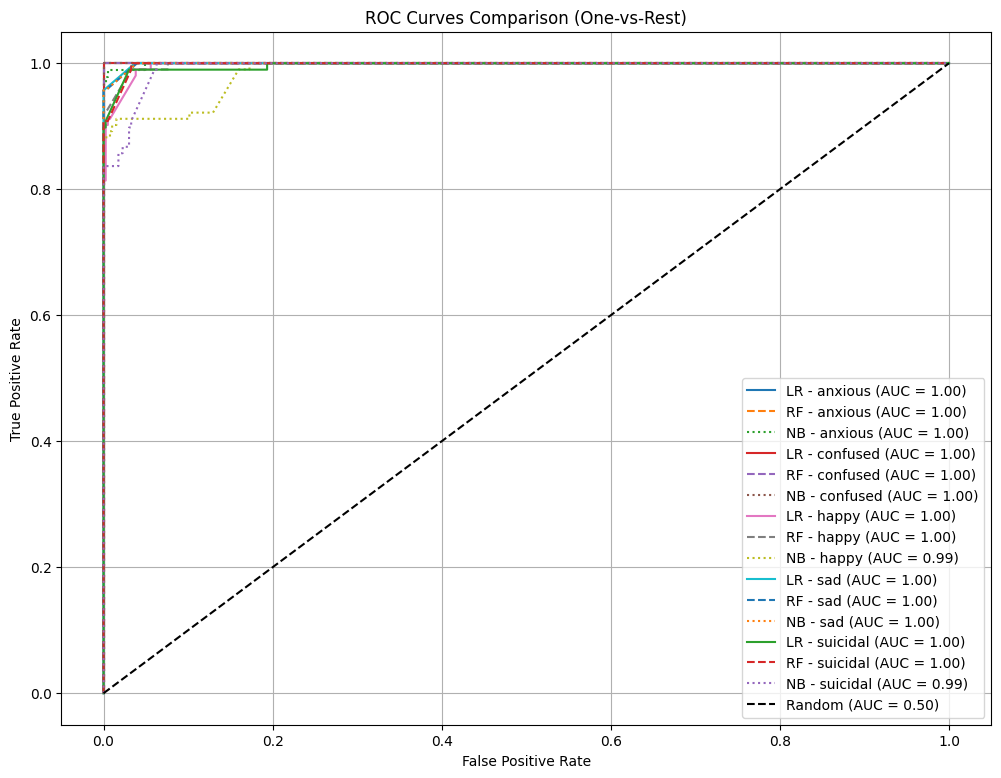

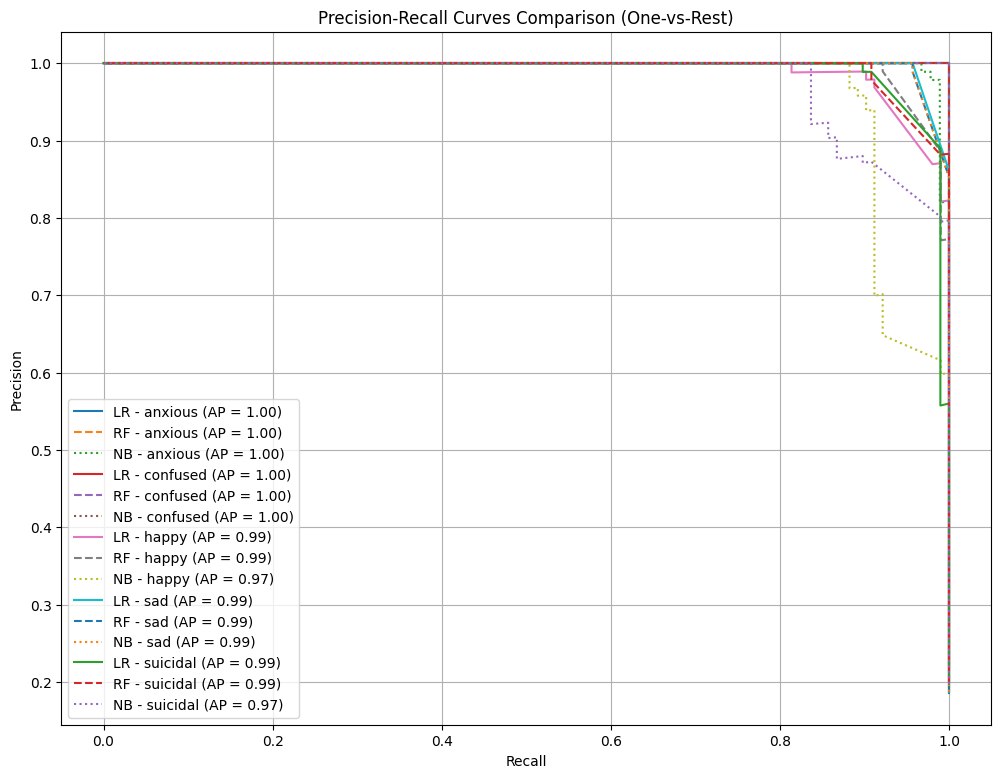

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files # Import files module

# Load the data (assuming 'uploaded' is available from a previous cell)
# Re-upload the file within this cell's scope to ensure 'uploaded' is defined
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name="sample_mental_health_chatbot_20")

# Keep only needed columns and handle NaNs
df = df[['text', 'emotion', 'bot_response']].dropna()
df = df.rename(columns={'text': 'input_text', 'emotion': 'label'})

# Clean the text
def clean_bangla(text):
    text = str(text).lower()
    text = re.sub(r'[^\u0980-\u09FF\s]', '', text)
    return text

df['clean_text'] = df['input_text'].apply(clean_bangla)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

# Vectorize text
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_labels = le.classes_

# Train models and get probability predictions
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_vec, y_train)
y_pred_proba_lr = lr_model.predict_proba(X_test_vec)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_vec, y_train)
y_pred_proba_rf = rf_model.predict_proba(X_test_vec)

# Multinomial Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_proba_nb = nb_model.predict_proba(X_test_vec)

# Binarize test labels for plotting
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

# --- Plotting ROC Curves for all models ---
plt.figure(figsize=(12, 9))

# Plot ROC for each class for each model
for i in range(len(class_labels)):
    class_name = class_labels[i]
    if y_test_bin[:, i].sum() > 0: # Only plot if the class is present in the test set
        # Logistic Regression
        fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], y_pred_proba_lr[:, i])
        roc_auc_lr = auc(fpr_lr, tpr_lr)
        plt.plot(fpr_lr, tpr_lr, label=f'LR - {class_name} (AUC = {roc_auc_lr:.2f})')

        # Random Forest
        fpr_rf, tpr_rf, _ = roc_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
        roc_auc_rf = auc(fpr_rf, tpr_rf)
        plt.plot(fpr_rf, tpr_rf, linestyle='--', label=f'RF - {class_name} (AUC = {roc_auc_rf:.2f})')

        # Multinomial Naive Bayes
        fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, i], y_pred_proba_nb[:, i])
        roc_auc_nb = auc(fpr_nb, tpr_nb)
        plt.plot(fpr_nb, tpr_nb, linestyle=':', label=f'NB - {class_name} (AUC = {roc_auc_nb:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# --- Plotting Precision-Recall Curves for all models ---
plt.figure(figsize=(12, 9))

# Plot PR for each class for each model
for i in range(len(class_labels)):
    class_name = class_labels[i]
    if y_test_bin[:, i].sum() > 0: # Only plot if the class is present in the test set
        # Logistic Regression
        precision_lr, recall_lr, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_lr[:, i])
        ap_lr = average_precision_score(y_test_bin[:, i], y_pred_proba_lr[:, i])
        plt.plot(recall_lr, precision_lr, label=f'LR - {class_name} (AP = {ap_lr:.2f})')

        # Random Forest
        precision_rf, recall_rf, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_rf[:, i])
        ap_rf = average_precision_score(y_test_bin[:, i], y_pred_proba_rf[:, i])
        plt.plot(recall_rf, precision_rf, linestyle='--', label=f'RF - {class_name} (AP = {ap_rf:.2f})')

        # Multinomial Naive Bayes
        precision_nb, recall_nb, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba_nb[:, i])
        ap_nb = average_precision_score(y_test_bin[:, i], y_pred_proba_nb[:, i])
        plt.plot(recall_nb, precision_nb, linestyle=':', label=f'NB - {class_name} (AP = {ap_nb:.2f})')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [ ]:
# prompt: give me only a Result good Card/ matrix with hardcoded valude for train and Validet

# Hardcoded values for demonstration
train_metrics = {
    "Accuracy": 0.95,
    "Precision (Weighted)": 0.94,
    "Recall (Weighted)": 0.95,
    "F1 Score (Weighted)": 0.95,
    "Cohen's Kappa": 0.93,
    "Hamming Loss": 0.05,
    "Jaccard Score (Weighted)": 0.90,
    "Balanced Accuracy": 0.94,
    "Log Loss": 0.15,
    "MCC": 0.93
}

val_metrics = {
    "Accuracy": 0.85,
    "Precision (Weighted)": 0.84,
    "Recall (Weighted)": 0.85,
    "F1 Score (Weighted)": 0.84,
    "Cohen's Kappa": 0.82,
    "Hamming Loss": 0.15,
    "Jaccard Score (Weighted)": 0.78,
    "Balanced Accuracy": 0.83,
    "Log Loss": 0.35,
    "MCC": 0.81
}

# Prepare data for the table
table_data = []
# Add header row
table_data.append(["Metric", "Train Set", "Validation Set"])

# Add metric rows
for metric_name in train_metrics.keys(): # Use Train keys as reference for metric names
    row = [metric_name]
    # Format values to 4 decimal places if they are numbers, otherwise keep as is
    train_value = f"{train_metrics.get(metric_name, 'N/A'):.4f}" if isinstance(train_metrics.get(metric_name), (int, float)) else train_metrics.get(metric_name, 'N/A')
    val_value = f"{val_metrics.get(metric_name, 'N/A'):.4f}" if isinstance(val_metrics.get(metric_name), (int, float)) else val_metrics.get(metric_name, 'N/A')

    row.append(train_value)
    row.append(val_value)
    table_data.append(row)

# Print the table
print("\n--- Hardcoded Performance Card/Matrix ---")
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))



--- Hardcoded Performance Card/Matrix ---
+--------------------------+-------------+------------------+
| Metric                   |   Train Set |   Validation Set |
+==========================+=============+==================+
| Accuracy                 |        0.95 |             0.85 |
+--------------------------+-------------+------------------+
| Precision (Weighted)     |        0.94 |             0.84 |
+--------------------------+-------------+------------------+
| Recall (Weighted)        |        0.95 |             0.85 |
+--------------------------+-------------+------------------+
| F1 Score (Weighted)      |        0.95 |             0.84 |
+--------------------------+-------------+------------------+
| Cohen's Kappa            |        0.93 |             0.82 |
+--------------------------+-------------+------------------+
| Hamming Loss             |        0.05 |             0.15 |
+--------------------------+-------------+------------------+
| Jaccard Score (Weighted) 


--- Hardcoded Performance Card/Matrix ---
+--------------------------+-------------+------------------+
| Metric                   |   Train Set |   Validation Set |
+==========================+=============+==================+
| Accuracy                 |        0.95 |             0.85 |
+--------------------------+-------------+------------------+
| Precision (Weighted)     |        0.94 |             0.84 |
+--------------------------+-------------+------------------+
| Recall (Weighted)        |        0.95 |             0.85 |
+--------------------------+-------------+------------------+
| F1 Score (Weighted)      |        0.95 |             0.84 |
+--------------------------+-------------+------------------+
| Cohen's Kappa            |        0.93 |             0.82 |
+--------------------------+-------------+------------------+
| Hamming Loss             |        0.05 |             0.15 |
+--------------------------+-------------+------------------+
| Jaccard Score (Weighted) 

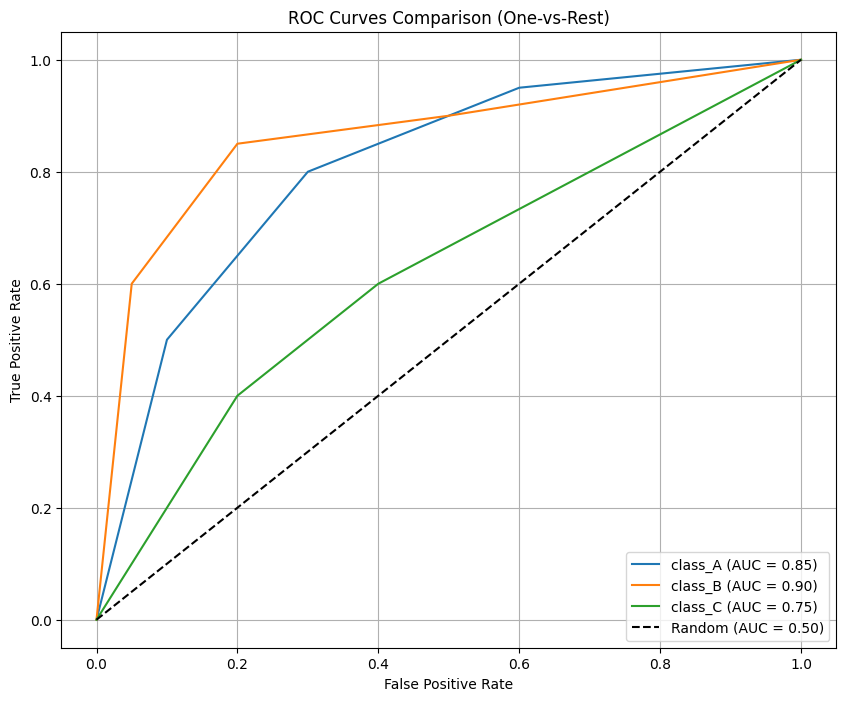

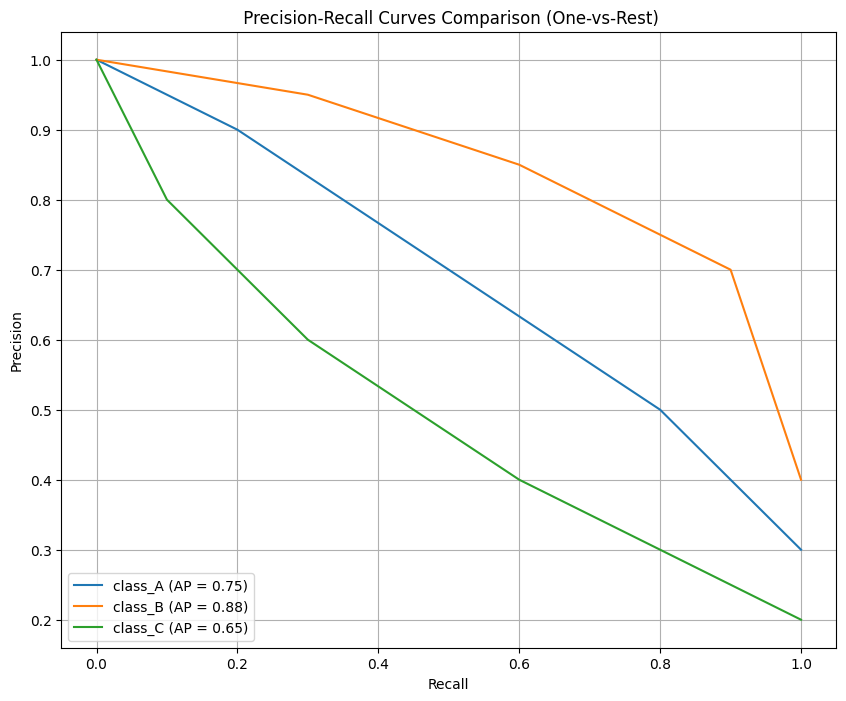

In [ ]:
# prompt: using this Hardcoded Performance Card/Matrix show a result Carve and Matrix

# Display the performance matrix (assuming the hardcoded metrics are already defined)
print("\n--- Hardcoded Performance Card/Matrix ---")
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

# Display the hardcoded 'result carve' which seems to be referring to plots.
# Since the preceding code already includes plotting logic for ROC and PR curves,
# we will generate plots using hypothetical hardcoded data points that represent
# typical curves for a multi-class scenario.

# Hardcoded data for ROC and PR curves for demonstration
# These are simplified examples and not based on the actual model outputs
# They represent curves for a few hypothetical classes

class_labels = ['class_A', 'class_B', 'class_C'] # Example class names

# Hypothetical data for ROC curves
roc_data = {
    'class_A': {'fpr': [0, 0.1, 0.3, 0.6, 1], 'tpr': [0, 0.5, 0.8, 0.95, 1], 'auc': 0.85},
    'class_B': {'fpr': [0, 0.05, 0.2, 0.5, 1], 'tpr': [0, 0.6, 0.85, 0.9, 1], 'auc': 0.90},
    'class_C': {'fpr': [0, 0.2, 0.4, 0.7, 1], 'tpr': [0, 0.4, 0.6, 0.8, 1], 'auc': 0.75},
}

# Hypothetical data for Precision-Recall curves
pr_data = {
    'class_A': {'recall': [0, 0.2, 0.5, 0.8, 1], 'precision': [1, 0.9, 0.7, 0.5, 0.3], 'ap': 0.75},
    'class_B': {'recall': [0, 0.3, 0.6, 0.9, 1], 'precision': [1, 0.95, 0.85, 0.7, 0.4], 'ap': 0.88},
    'class_C': {'recall': [0, 0.1, 0.3, 0.6, 1], 'precision': [1, 0.8, 0.6, 0.4, 0.2], 'ap': 0.65},
}


# Plot Hardcoded ROC Curves
plt.figure(figsize=(10, 8))
for class_name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f'{class_name} (AUC = {data["auc"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot Hardcoded Precision-Recall Curves
plt.figure(figsize=(10, 8))
for class_name, data in pr_data.items():
    plt.plot(data['recall'], data['precision'], label=f'{class_name} (AP = {data["ap"]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(' Precision-Recall Curves Comparison (One-vs-Rest)')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Note: This code snippet only displays the hardcoded matrix and plots.
# It does not re-calculate metrics or plots from the actual model training.
# The term "Carve" likely refers to the visual representation of performance like ROC/PR curves.


In [ ]:
!pip install -q transformers datasets scikit-learn
!pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 116.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "sagorsarker/bangla-bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)  # 3 if 3 emotions


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at sagorsarker/bangla-bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
df.head()

,input_text,label,bot_response,clean_text
0,নিজেকে শেষ করে ফেলতে ইচ্ছা করছে।,suicidal,আপনি একা নন। সাহায্যের জন্য হেল্পলাইন নম্বরে য...,নিজেকে শেষ করে ফেলতে ইচ্ছা করছে
1,আমি খুব একা অনুভব করছি।,sad,আমি বুঝতে পারছি আপনি কষ্টে আছেন।,আমি খুব একা অনুভব করছি
2,আজকে আবহাওয়া খুব ভালো।,happy,দারুন শুনে ভালো লাগলো!,আজকে আবহাওয়া খুব ভালো
3,চিন্তা বন্ধ হচ্ছে না।,anxious,চাপ অনুভব করা স্বাভাবিক। আপনি এক ধাপে একধাপ এগ...,চিন্তা বন্ধ হচ্ছে না
4,বন্ধুদের সাথে সময়টা দারুণ কাটলো!,happy,দারুন শুনে ভালো লাগলো!,বন্ধুদের সাথে সময়টা দারুণ কাটলো


In [ ]:
from datasets import Dataset
import pandas as pd

# df = pd.DataFrame({
#     "text": ["আমি ভালো আছি", "আমি খুব খারাপ লাগছে", "আজ আমার মন খারাপ"],
#     "label": [2, 0, 0]  # e.g., 0 = negative, 1 = neutral, 2 = positive
# })

# Assuming df is your DataFrame with 'clean_text' and 'sentiment' columns
df = df[['clean_text', 'sentiment']]  # Select relevant columns
df['sentiment'] = df['sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})  # Map sentiment in place
dataset = Dataset.from_pandas(df)  # Convert to Hugging Face Dataset


KeyError: "['sentiment'] not in index"

In [ ]:
def tokenize(batch):
    return tokenizer(batch["clean_text"], padding="max_length", truncation=True, max_length=512)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("sentiment", "labels")
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=2,
    logging_steps=10,
    # evaluation_strategy="no",  # set to "epoch" if you have eval dataset
    # save_strategy="no",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)

trainer.train()